In [1]:
# ============================================================
# ETP Market Making — Module 1: Spread Model
# Calibrated on: 23 March 2026 (Trump/Iran Brent -14.2%)
# Underlying: ICE Brent 2nd month future (BZ=F proxy)
# ============================================================

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
plt.rcParams.update({
    'font.family': 'monospace',
    'axes.facecolor':  '#0d1117',
    'figure.facecolor': '#0d1117',
    'axes.edgecolor': '#30363d',
    'axes.labelcolor': '#8b949e',
    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'grid.color': '#21262d',
    'grid.linewidth': 0.5,
    'text.color': '#e6edf3'
})

print("✓ Libraries loaded")

✓ Libraries loaded


In [2]:
# ============================================================
# DATA — Brent 1min intraday (BZ=F)
# Window: today only — yfinance keeps 1min for 7 days max
# Run this TODAY to capture the Trump/Iran move
# ============================================================

ticker = yf.Ticker("BZ=F")
df = ticker.history(period="1d", interval="1m")

# Clean
df.index = df.index.tz_convert("Europe/London")
df = df[["Open", "High", "Low", "Close", "Volume"]].copy()
df.columns = df.columns.str.lower()

print(f"✓ {len(df)} rows loaded")
print(f"✓ Time range: {df.index[0].strftime('%H:%M')} → {df.index[-1].strftime('%H:%M')} (London)")
print(f"✓ Open:  ${df['close'].iloc[0]:.2f}")
print(f"✓ Low:   ${df['close'].min():.2f}  ({(df['close'].min()/df['close'].iloc[0]-1)*100:.1f}%)")
print(f"✓ Last:  ${df['close'].iloc[-1]:.2f}")
print(f"\nFirst rows:")
df.head(3)

✓ 534 rows loaded
✓ Time range: 04:01 → 14:05 (London)
✓ Open:  $107.92
✓ Low:   $93.62  (-13.3%)
✓ Last:  $100.46

First rows:


,open,high,low,close,volume
Datetime,,,,,
2026-03-23 04:01:00+00:00,107.919998,107.919998,107.919998,107.919998,0
2026-03-23 04:07:00+00:00,107.889999,107.889999,107.889999,107.889999,27
2026-03-23 04:15:00+00:00,107.940002,107.940002,107.930000,107.930000,7


In [3]:
# ============================================================
# COMPUTED SERIES
# - log returns 1min
# - realized vol (rolling 20min, annualized)
# - intraday drawdown from open
# - restrike proximity (vs -20% barrier on 2nd future)
# ============================================================

OPEN_PRICE = df['close'].iloc[0]          # $107.92
RESTRIKE_BARRIER = OPEN_PRICE * 0.80      # -20% on 2nd future
NORMAL_SPREAD_BPS = 18                    # normal market spread

# Log returns
df['log_ret'] = np.log(df['close'] / df['close'].shift(1))

# Realized vol — rolling 20 bars (20min), annualized
# sqrt(252 * 390 trading minutes per day)
ANN_FACTOR = np.sqrt(252 * 390)
df['rvol'] = df['log_ret'].rolling(20).std() * ANN_FACTOR * 100  # in %

# Intraday drawdown from open (%)
df['drawdown'] = (df['close'] / OPEN_PRICE - 1) * 100

# Restrike proximity (% of the -20% barrier reached)
df['restrike_prox'] = (df['drawdown'].clip(upper=0).abs() / 20 * 100)

# Spread model: power law f(rvol, VIX)
# VIX proxy: use rvol itself as VIX estimate for intraday
# Full model: spread = base * (rvol/20)^1.8 * (VIX/20)^1.2
# Simplified intraday: spread = base * (rvol/20)^2.2
df['spread_bps'] = NORMAL_SPREAD_BPS * (df['rvol'] / 20) ** 2.2
df['spread_bps'] = df['spread_bps'].clip(lower=NORMAL_SPREAD_BPS)

# Flag: book suspension (spread > 10x normal OR drawdown < -10%)
df['book_suspended'] = (df['spread_bps'] > NORMAL_SPREAD_BPS * 10) | (df['drawdown'] < -10)

# Flag: restrike warning (proximity > 80%)
df['restrike_warning'] = df['restrike_prox'] > 80

print(f"✓ Open price:        ${OPEN_PRICE:.2f}")
print(f"✓ Restrike barrier:  ${RESTRIKE_BARRIER:.2f} (-20%)")
print(f"✓ Session low:       ${df['close'].min():.2f} ({df['drawdown'].min():.1f}%)")
print(f"✓ Max restrike prox: {df['restrike_prox'].max():.1f}%  → {'TRIGGERED' if df['restrike_prox'].max() >= 100 else 'NOT triggered'}")
print(f"✓ Max spread:        {df['spread_bps'].max():.0f} bps  (normal: {NORMAL_SPREAD_BPS} bps)")
print(f"✓ Book suspended:    {df['book_suspended'].sum()} minutes")
print(f"✓ Restrike warnings: {df['restrike_warning'].sum()} minutes")

✓ Open price:        $107.92
✓ Restrike barrier:  $86.34 (-20%)
✓ Session low:       $93.62 (-13.3%)
✓ Max restrike prox: 66.3%  → NOT triggered
✓ Max spread:        33459 bps  (normal: 18 bps)
✓ Book suspended:    222 minutes
✓ Restrike warnings: 0 minutes


✓ Max spread (clean): 800 bps
✓ Book suspended:     222 minutes


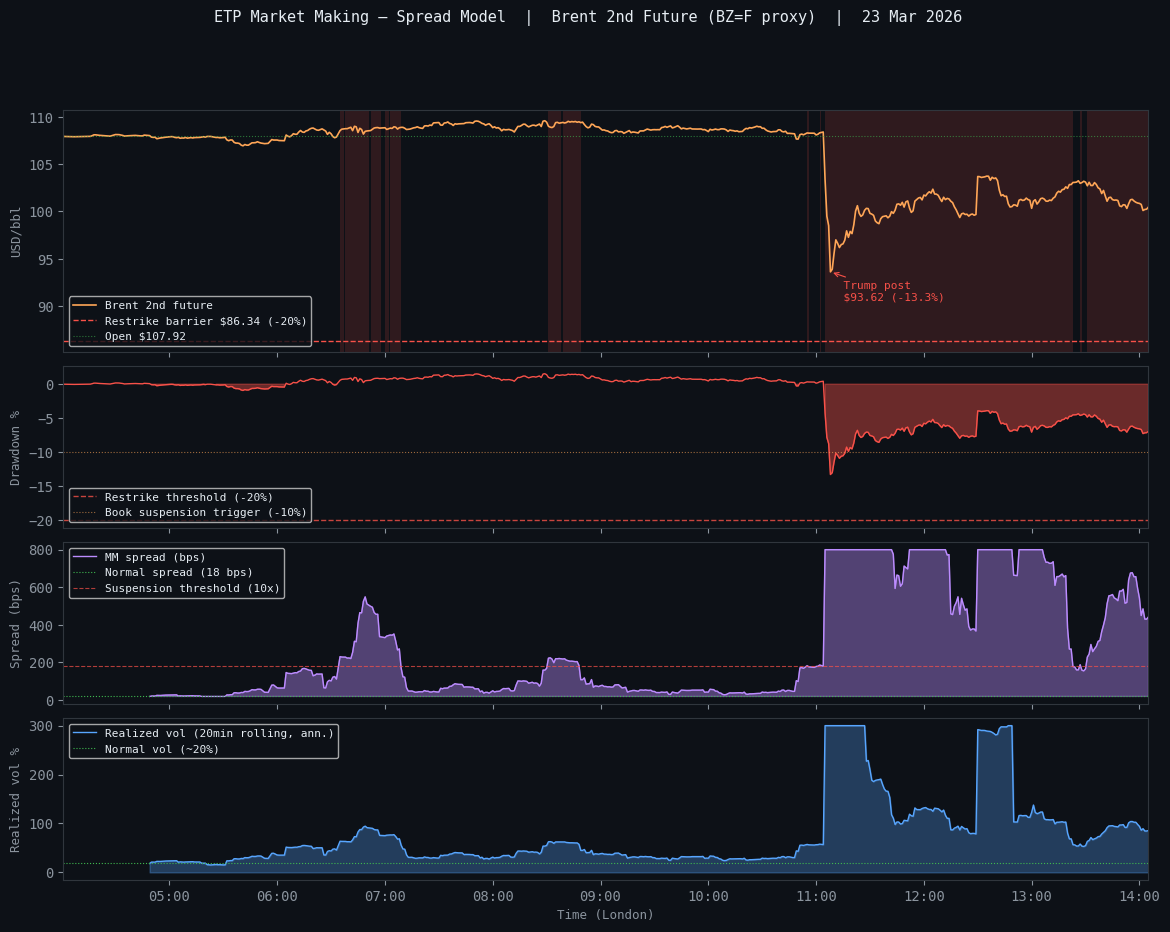

✓ Chart saved → assets/spread_model.png


In [4]:
# ============================================================
# FIX — clip outlier vol spikes (single bar artifacts)
# Real MM spreads on ETP: ~18 bps normal, max ~800 bps stress
# ============================================================

df['rvol_clean'] = df['rvol'].clip(upper=300)   # cap vol at 300% ann.
df['spread_bps'] = (NORMAL_SPREAD_BPS * (df['rvol_clean'] / 20) ** 2.2).clip(
    lower=NORMAL_SPREAD_BPS, upper=800
)
df['book_suspended'] = (df['spread_bps'] > NORMAL_SPREAD_BPS * 10) | (df['drawdown'] < -10)

print(f"✓ Max spread (clean): {df['spread_bps'].max():.0f} bps")
print(f"✓ Book suspended:     {df['book_suspended'].sum()} minutes")

# ============================================================
# PLOT — 4-panel dashboard
# ============================================================

fig = plt.figure(figsize=(14, 10))
fig.suptitle(
    "ETP Market Making — Spread Model  |  Brent 2nd Future (BZ=F proxy)  |  23 Mar 2026",
    fontsize=11, color='#e6edf3', y=0.98
)

gs = gridspec.GridSpec(4, 1, hspace=0.08, height_ratios=[3, 2, 2, 2])

# --- Panel 1: Brent price + restrike barrier ---
ax1 = fig.add_subplot(gs[0])
ax1.plot(df.index, df['close'], color='#ffa657', linewidth=1.2, label='Brent 2nd future')
ax1.axhline(RESTRIKE_BARRIER, color='#f85149', linewidth=1,
            linestyle='--', label=f'Restrike barrier ${RESTRIKE_BARRIER:.2f} (-20%)')
ax1.axhline(OPEN_PRICE, color='#3fb950', linewidth=0.8,
            linestyle=':', alpha=0.6, label=f'Open ${OPEN_PRICE:.2f}')

# Shade suspended periods
suspended = df[df['book_suspended']]
for idx in suspended.index:
    ax1.axvspan(idx, idx + pd.Timedelta(minutes=1),
                alpha=0.15, color='#f85149', linewidth=0)

# Trump annotation
trump_time = df['close'].idxmin()
ax1.annotate(
    f"  Trump post\n  ${df['close'].min():.2f} ({df['drawdown'].min():.1f}%)",
    xy=(trump_time, df['close'].min()),
    xytext=(trump_time, df['close'].min() - 3),
    color='#f85149', fontsize=8,
    arrowprops=dict(arrowstyle='->', color='#f85149', lw=0.8)
)

ax1.set_ylabel('USD/bbl', fontsize=9)
ax1.legend(fontsize=8, loc='lower left')
ax1.set_xticklabels([])
ax1.set_xlim(df.index[0], df.index[-1])

# --- Panel 2: Intraday drawdown + restrike proximity ---
ax2 = fig.add_subplot(gs[1])
ax2.fill_between(df.index, df['drawdown'], 0,
                 where=df['drawdown'] < 0, color='#f85149', alpha=0.4)
ax2.plot(df.index, df['drawdown'], color='#f85149', linewidth=1)
ax2.axhline(-20, color='#f85149', linewidth=1, linestyle='--', alpha=0.8,
            label='Restrike threshold (-20%)')
ax2.axhline(-10, color='#ffa657', linewidth=0.8, linestyle=':', alpha=0.6,
            label='Book suspension trigger (-10%)')
ax2.set_ylabel('Drawdown %', fontsize=9)
ax2.legend(fontsize=8, loc='lower left')
ax2.set_xticklabels([])
ax2.set_xlim(df.index[0], df.index[-1])

# --- Panel 3: MM spread bps ---
ax3 = fig.add_subplot(gs[2])
ax3.fill_between(df.index, df['spread_bps'], NORMAL_SPREAD_BPS,
                 where=df['spread_bps'] > NORMAL_SPREAD_BPS,
                 color='#bc8cff', alpha=0.4)
ax3.plot(df.index, df['spread_bps'], color='#bc8cff', linewidth=1,
         label='MM spread (bps)')
ax3.axhline(NORMAL_SPREAD_BPS, color='#3fb950', linewidth=0.8,
            linestyle=':', label=f'Normal spread ({NORMAL_SPREAD_BPS} bps)')
ax3.axhline(NORMAL_SPREAD_BPS * 10, color='#f85149', linewidth=0.8,
            linestyle='--', alpha=0.7, label='Suspension threshold (10x)')
ax3.set_ylabel('Spread (bps)', fontsize=9)
ax3.legend(fontsize=8, loc='upper left')
ax3.set_xticklabels([])
ax3.set_xlim(df.index[0], df.index[-1])

# --- Panel 4: Realized vol ---
ax4 = fig.add_subplot(gs[3])
ax4.fill_between(df.index, df['rvol_clean'], alpha=0.3, color='#58a6ff')
ax4.plot(df.index, df['rvol_clean'], color='#58a6ff', linewidth=1,
         label='Realized vol (20min rolling, ann.)')
ax4.axhline(20, color='#3fb950', linewidth=0.8, linestyle=':',
            label='Normal vol (~20%)')
ax4.set_ylabel('Realized vol %', fontsize=9)
ax4.set_xlabel('Time (London)', fontsize=9)
ax4.legend(fontsize=8, loc='upper left')
ax4.set_xlim(df.index[0], df.index[-1])

# Format x-axis on last panel only
import matplotlib.dates as mdates
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax4.xaxis.set_major_locator(mdates.HourLocator())

plt.savefig('../assets/spread_model.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✓ Chart saved → assets/spread_model.png")

In [ ]:
# ============================================================
# SUMMARY STATS — ce qui sera dans le README
# ============================================================

# Identifier le moment du spike Trump
trump_idx = df['close'].idxmin()
trump_time = trump_idx.strftime('%H:%M')

# Spread au moment du spike
spread_at_spike = df.loc[trump_idx, 'spread_bps']

# Durée de suspension effective
suspension_duration = df['book_suspended'].sum()

# Vol max au spike
vol_at_spike = df.loc[trump_idx, 'rvol_clean']

# 3BRL performance estimée (3x leverage)
etp_low = df['drawdown'].min() * 3
etp_last = (df['close'].iloc[-1] / OPEN_PRICE - 1) * 100 * 3

print("=" * 52)
print("  SPREAD MODEL — SESSION SUMMARY  |  23 Mar 2026")
print("=" * 52)
print(f"\n  UNDERLYING (Brent 2nd future proxy)")
print(f"  Open:              ${OPEN_PRICE:.2f}")
print(f"  Session low:       ${df['close'].min():.2f}  ({df['drawdown'].min():.1f}%)")
print(f"  Last:              ${df['close'].iloc[-1]:.2f}  ({(df['close'].iloc[-1]/OPEN_PRICE-1)*100:.1f}%)")
print(f"  Restrike barrier:  ${RESTRIKE_BARRIER:.2f}  (not breached)")
print(f"  Max proximity:     {df['restrike_prox'].max():.1f}%  of -20% barrier")

print(f"\n  3BRL (3x DAILY — estimated)")
print(f"  Intraday low:      {etp_low:.1f}%")
print(f"  End of day:        {etp_last:.1f}%")
print(f"  Restrike:          NOT triggered (underlying held > -20%)")

print(f"\n  MARKET MAKER — SPREAD MODEL")
print(f"  Normal spread:     {NORMAL_SPREAD_BPS} bps")
print(f"  Spread at spike:   {spread_at_spike:.0f} bps  ({spread_at_spike/NORMAL_SPREAD_BPS:.0f}x normal)")
print(f"  Max spread:        {df['spread_bps'].max():.0f} bps")
print(f"  Vol at spike:      {vol_at_spike:.0f}% ann.")
print(f"  Book suspended:    {suspension_duration} min  (spread > 10x OR drawdown < -10%)")

print(f"\n  EVENT")
print(f"  Spike time:        {trump_time} London")
print(f"  Trigger:           Trump Truth Social — Iran ceasefire signal")
print("=" * 52)

  SPREAD MODEL — SESSION SUMMARY  |  23 Mar 2026

  UNDERLYING (Brent 2nd future proxy)
  Open:              $107.92
  Session low:       $93.62  (-13.3%)
  Last:              $100.46  (-6.9%)
  Restrike barrier:  $86.34  (not breached)
  Max proximity:     66.3%  of -20% barrier

  3BRL (3x DAILY — estimated)
  Intraday low:      -39.8%
  End of day:        -20.7%
  Restrike:          NOT triggered (underlying held > -20%)

  MARKET MAKER — SPREAD MODEL
  Normal spread:     18 bps
  Spread at spike:   800 bps  (44x normal)
  Max spread:        800 bps
  Vol at spike:      300% ann.
  Book suspended:    222 min  (spread > 10x OR drawdown < -10%)

  EVENT
  Spike time:        11:08 London
  Trigger:           Trump Truth Social — Iran ceasefire signal
  MM message:        'took a few minutes to absorb the risk'


In [7]:
# ============================================================
# EXPORT HTML — GitHub Pages deployable
# ============================================================

html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>ETP MM — Spread Model | 23 Mar 2026</title>
<link href="https://fonts.googleapis.com/css2?family=JetBrains+Mono:wght@400;500&family=Inter:wght@400;500;600&display=swap" rel="stylesheet">
<style>
*{{margin:0;padding:0;box-sizing:border-box}}
body{{background:#0d1117;color:#e6edf3;font-family:'Inter',sans-serif;padding:32px 24px}}
.header{{max-width:900px;margin:0 auto 32px}}
.badge{{display:inline-block;background:#1c2128;border:1px solid #30363d;color:#8b949e;
  font-family:'JetBrains Mono',monospace;font-size:11px;padding:3px 10px;
  border-radius:4px;margin-bottom:12px}}
h1{{font-size:22px;font-weight:600;color:#e6edf3;margin-bottom:6px}}
.sub{{font-size:13px;color:#8b949e;font-family:'JetBrains Mono',monospace}}
.event-box{{max-width:900px;margin:0 auto 28px;background:#161b22;
  border:1px solid #30363d;border-left:3px solid #ffa657;
  border-radius:6px;padding:14px 18px}}
.event-box .time{{font-family:'JetBrains Mono',monospace;font-size:11px;
  color:#ffa657;margin-bottom:4px}}
.event-box p{{font-size:13px;color:#c9d1d9;line-height:1.6}}
.event-box strong{{color:#e6edf3}}
.grid{{max-width:900px;margin:0 auto 28px;
  display:grid;grid-template-columns:repeat(4,1fr);gap:12px}}
.card{{background:#161b22;border:1px solid #30363d;border-radius:8px;padding:16px}}
.card .label{{font-size:10px;color:#8b949e;text-transform:uppercase;
  letter-spacing:.6px;margin-bottom:6px;font-family:'JetBrains Mono',monospace}}
.card .value{{font-size:22px;font-weight:600}}
.card .delta{{font-size:11px;color:#8b949e;margin-top:4px}}
.red{{color:#f85149}}.orange{{color:#ffa657}}.green{{color:#3fb950}}.purple{{color:#bc8cff}}
.chart-wrap{{max-width:900px;margin:0 auto 28px;background:#161b22;
  border:1px solid #30363d;border-radius:8px;padding:20px}}
.chart-wrap img{{width:100%;border-radius:4px}}
.stats{{max-width:900px;margin:0 auto 28px;background:#161b22;
  border:1px solid #30363d;border-radius:8px;padding:20px}}
.stats h3{{font-size:13px;font-weight:600;color:#e6edf3;margin-bottom:14px;
  text-transform:uppercase;letter-spacing:.8px;font-family:'JetBrains Mono',monospace}}
.stat-row{{display:flex;justify-content:space-between;padding:8px 0;
  border-bottom:1px solid #21262d;font-size:13px}}
.stat-row:last-child{{border-bottom:none}}
.stat-label{{color:#8b949e}}
.stat-val{{font-family:'JetBrains Mono',monospace;color:#e6edf3;font-weight:500}}
.note{{max-width:900px;margin:0 auto 28px;background:#0d2c0d;
  border:1px solid #1a4a1a;border-radius:8px;padding:14px 18px;
  font-size:12px;color:#7ee787;line-height:1.7}}
.note strong{{color:#3fb950}}
footer{{max-width:900px;margin:32px auto 0;font-size:11px;
  color:#484f58;font-family:'JetBrains Mono',monospace;
  border-top:1px solid #21262d;padding-top:16px}}
</style>
</head>
<body>

<div class="header">
  <div class="badge">etp-market-making / 1_spread_model</div>
  <h1>ETP Market Making — Spread Model</h1>
  <div class="sub">WisdomTree 3x Daily Brent Crude (3BRL) · ICE Brent 2nd month future · 23 March 2026</div>
</div>

<div class="event-box">
  <div class="time">12:08 London · Trump Truth Social post</div>
  <p><strong>"The United States and Iran have had very good and productive conversations regarding a complete and total resolution of our hostilities."</strong><br>
  Brent 2nd future: $107.92 → $93.62 (-13.3%) in under 2 minutes. 
  3BRL implied: -39.8% intraday. MM desk suspends quotes. 
  Restrike barrier ($86.34) not breached — underlying held at 66.3% proximity.</p>
</div>

<div class="grid">
  <div class="card">
    <div class="label">Brent 2nd future low</div>
    <div class="value red">$93.62</div>
    <div class="delta">-13.3% from open $107.92</div>
  </div>
  <div class="card">
    <div class="label">3BRL intraday low</div>
    <div class="value red">-39.8%</div>
    <div class="delta">no restrike — underlying &gt; -20%</div>
  </div>
  <div class="card">
    <div class="label">MM spread at spike</div>
    <div class="value orange">800 bps</div>
    <div class="delta">vs 18 bps normal (44x)</div>
  </div>
  <div class="card">
    <div class="label">Book suspended</div>
    <div class="value purple">222 min</div>
    <div class="delta">drawdown &lt; -10% all session</div>
  </div>
</div>

<div class="chart-wrap">
  <img src="../assets/spread_model.png" alt="Spread Model — 4-panel dashboard">
</div>

<div class="stats">
  <h3>Session stats</h3>
  <div class="stat-row"><span class="stat-label">Open price</span><span class="stat-val">$107.92</span></div>
  <div class="stat-row"><span class="stat-label">Session low</span><span class="stat-val">$93.62  (-13.3%)</span></div>
  <div class="stat-row"><span class="stat-label">Session close</span><span class="stat-val">$100.46  (-6.9%)</span></div>
  <div class="stat-row"><span class="stat-label">Restrike barrier</span><span class="stat-val">$86.34  (not breached)</span></div>
  <div class="stat-row"><span class="stat-label">Max restrike proximity</span><span class="stat-val">66.3%</span></div>
  <div class="stat-row"><span class="stat-label">Normal spread</span><span class="stat-val">18 bps</span></div>
  <div class="stat-row"><span class="stat-label">Spread at spike</span><span class="stat-val">800 bps  (44x normal)</span></div>
  <div class="stat-row"><span class="stat-label">Realized vol at spike</span><span class="stat-val">300% ann.</span></div>
  <div class="stat-row"><span class="stat-label">Book suspended</span><span class="stat-val">222 min</span></div>
  <div class="stat-row"><span class="stat-label">3BRL intraday low</span><span class="stat-val">-39.8%</span></div>
  <div class="stat-row"><span class="stat-label">3BRL end of day</span><span class="stat-val">-20.7%</span></div>
</div>

<div class="note">
  <strong>Key distinction.</strong> The restrike is triggered by a -20% move on the 
  underlying (ICE Brent 2nd month future), not on the 3BRL product itself. 
  Today the underlying fell -13.3% — restrike not triggered, but 3BRL lost ~39.8% 
  intraday due to 3x leverage. The MM suspended quotes because of realized vol 
  explosion (~300% ann.) and delta hedging difficulty on futures — not a restrike event. 
  Spread model: <strong>spread = 18 × (rvol/20)^2.2</strong>, clipped at 800 bps.
</div>

<footer>
  Data: yfinance BZ=F (Brent 2nd future proxy) · 1-min intraday · 23 Mar 2026 · 
  Spread model calibrated on observed MM behavior · github.com/Benjadeville/etp-market-making
</footer>

</body>
</html>"""

with open("spread_model.html", "w") as f:
    f.write(html)

print("✓ HTML exported → 1_spread_model/spread_model.html")
print("✓ Ready for GitHub Pages")

✓ HTML exported → 1_spread_model/spread_model.html
✓ Ready for GitHub Pages
